# Notebook 3: PPO Fine-Tuning

---

## Overview
This notebook implements **Stage 3**: PPO-based RL fine-tuning of the SFT policy 
using the trained reward model as the reward signal.

**Objective (InstructGPT):**

$$\max_{\pi_\theta} \mathbb{E}_{x \sim \mathcal{D}, y \sim \pi_\theta(\cdot|x)} [r_\phi(x,y)] - \beta \cdot KL[\pi_\theta(\cdot|x) \| \pi_{SFT}(\cdot|x)]$$

The KL penalty prevents reward hacking and keeps the policy close to the reference SFT model.

**Pipeline position:**
```
[SFT] → [Reward Modeling] → [PPO Fine-Tuning]
```


## 1. Setup

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm
import json, math, time, platform

torch.manual_seed(42)
np.random.seed(42)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    props = torch.cuda.get_device_properties(0)
    USE_BF16 = props.major >= 8
    AMP_DTYPE = torch.bfloat16 if USE_BF16 else torch.float16
    print(f"Mixed precision: {'bf16' if USE_BF16 else 'fp16'}")
else:
    USE_BF16 = False
    AMP_DTYPE = torch.float32

#  Detect TRL version and available API 
TRL_AVAILABLE = False
TRL_VERSION   = None
USE_TRL       = False   # set True below if a compatible version found

try:
    import trl
    TRL_VERSION = trl.__version__
    from packaging.version import Version
    v = Version(TRL_VERSION)

    if v >= Version("0.9.0"):
        # TRL ≥ 0.9: PPOv2Trainer + new config location
        try:
            from trl import PPOv2Trainer
            from trl.trainer.ppo_config import PPOConfig as PPOv2Config
            from trl.models import AutoModelForCausalLMWithValueHead
            from trl import create_reference_model
            TRL_API = "v2"
            TRL_AVAILABLE = True
            USE_TRL = True
            print(f"TRL {TRL_VERSION} — using PPOv2Trainer API")
        except ImportError:
            pass

    if not TRL_AVAILABLE and v >= Version("0.4.0"):
        # TRL 0.4–0.8: classic PPOTrainer
        try:
            from trl import PPOTrainer, PPOConfig
            from trl.models import AutoModelForCausalLMWithValueHead
            from trl import create_reference_model
            TRL_API = "v1"
            TRL_AVAILABLE = True
            USE_TRL = True
            print(f"TRL {TRL_VERSION} — using PPOTrainer (classic) API")
        except ImportError:
            pass

    if not TRL_AVAILABLE:
        print(f"TRL {TRL_VERSION} found but no compatible PPO API — using manual PPO")

except ImportError:
    print("TRL not installed — using self-contained manual PPO implementation")

if not USE_TRL:
    print("Mode: Manual PPO (no TRL dependency)")


Device: cuda
GPU: NVIDIA GeForce RTX 2070 with Max-Q Design
Mixed precision: fp16
TRL 0.29.0 found but no compatible PPO API — using manual PPO
Mode: Manual PPO (no TRL dependency)


## 2. Configuration

In [2]:
class PPOTrainConfig:
    SFT_DIR  = "./checkpoints/sft"
    RM_DIR   = "./checkpoints/rm"
    OUT_DIR  = "./checkpoints/ppo"
    BASE     = "gpt2"

    # PPO hyperparameters
    LEARNING_RATE    = 1e-5
    BATCH_SIZE       = 8          # rollout batch size
    MINI_BATCH_SIZE  = 4          # PPO inner mini-batch
    PPO_EPOCHS       = 4          # inner update epochs per rollout
    KL_COEFF         = 0.1        # β — KL penalty weight
    CLIP_RANGE       = 0.2        # PPO ε
    CLIP_RANGE_VALUE = 0.2
    MAX_GRAD_NORM    = 1.0
    GAMMA            = 1.0        # no discounting
    LAM              = 0.95       # GAE lambda

    # Generation
    MAX_NEW_TOKENS   = 100
    TEMPERATURE      = 0.7
    TOP_P            = 0.9

    # Training
    TOTAL_PPO_STEPS  = 200        # rollout batches 
    LOG_STEPS        = 10
    SAVE_STEPS       = 50

    # Data
    DATASET_NAME     = "Anthropic/hh-rlhf"
    PROMPT_MAX_LEN   = 128

cfg = PPOTrainConfig()
Path(cfg.OUT_DIR).mkdir(parents=True, exist_ok=True)
print("PPO Config")
print(f"  KL coefficient β:  {cfg.KL_COEFF}")
print(f"  PPO clip ε:        {cfg.CLIP_RANGE}")
print(f"  Rollout steps:     {cfg.TOTAL_PPO_STEPS}")
print(f"  Batch size:        {cfg.BATCH_SIZE}")


PPO Config
  KL coefficient β:  0.1
  PPO clip ε:        0.2
  Rollout steps:     200
  Batch size:        8


## 3. Load Models

In [3]:
# Tokenizer 
tokenizer = AutoTokenizer.from_pretrained(cfg.BASE)
tokenizer.pad_token     = tokenizer.eos_token
tokenizer.padding_side  = "left"   # for generation — pad on the left

#  Policy model
if USE_TRL:
    from trl.models import AutoModelForCausalLMWithValueHead
    policy = AutoModelForCausalLMWithValueHead.from_pretrained(
        cfg.SFT_DIR if Path(cfg.SFT_DIR).exists() else cfg.BASE
    ).to(DEVICE)
    ref_model = create_reference_model(policy)
    print("Policy + value head loaded (TRL) ✅")
else:
    # Manual PPO: separate policy LM and value head
    policy_lm = AutoModelForCausalLM.from_pretrained(
        cfg.SFT_DIR if Path(cfg.SFT_DIR).exists() else cfg.BASE
    ).to(DEVICE)

    # Frozen reference model for KL
    ref_lm = AutoModelForCausalLM.from_pretrained(
        cfg.SFT_DIR if Path(cfg.SFT_DIR).exists() else cfg.BASE
    ).to(DEVICE)
    for p in ref_lm.parameters():
        p.requires_grad_(False)
    ref_lm.eval()

    # Lightweight value head: maps last hidden state → scalar V(s)
    hidden_size = policy_lm.config.hidden_size
    value_head  = nn.Sequential(
        nn.Linear(hidden_size, hidden_size // 2),
        nn.GELU(),
        nn.Linear(hidden_size // 2, 1)
    ).to(DEVICE)

    print(f"Policy LM loaded (manual PPO)  [{sum(p.numel() for p in policy_lm.parameters())/1e6:.1f}M params]")
    print(f"Reference LM frozen")
    print(f"Value head: {sum(p.numel() for p in value_head.parameters())/1e3:.1f}K params")


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 0it [00:00, ?it/s]

GPT2LMHeadModel LOAD REPORT from: ./checkpoints/sft
Key                                                                       | Status     | 
--------------------------------------------------------------------------+------------+-
base_model.model.transformer.h.{0...11}.mlp.c_proj.lora_B.default.weight  | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_proj.lora_B.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_attn.lora_A.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_proj.lora_A.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_attn.lora_B.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.mlp.c_proj.lora_A.default.weight  | UNEXPECTED | 
transformer.h.{0...11}.mlp.c_proj.lora_B.default.weight                   | MISSING    | 
transformer.h.{0...11}.attn.c_proj.lora_B.default.weight                  | MISSING    | 
transformer.h.{0...11}.mlp.c_proj.lora_A.default

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 0it [00:00, ?it/s]

GPT2LMHeadModel LOAD REPORT from: ./checkpoints/sft
Key                                                                       | Status     | 
--------------------------------------------------------------------------+------------+-
base_model.model.transformer.h.{0...11}.mlp.c_proj.lora_B.default.weight  | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_proj.lora_B.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_attn.lora_A.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_proj.lora_A.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_attn.lora_B.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.mlp.c_proj.lora_A.default.weight  | UNEXPECTED | 
transformer.h.{0...11}.mlp.c_proj.lora_B.default.weight                   | MISSING    | 
transformer.h.{0...11}.attn.c_proj.lora_B.default.weight                  | MISSING    | 
transformer.h.{0...11}.mlp.c_proj.lora_A.default

Policy LM loaded (manual PPO)  [126.1M params]
Reference LM frozen
Value head: 295.7K params


In [ ]:
# Reward Model 
class RewardModel(nn.Module):
    def __init__(self, base_model_name, hidden_dim=768):
        super().__init__()
        from transformers import AutoModel
        self.backbone = AutoModel.from_pretrained(base_model_name)
        self.reward_head = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim // 2, 1)
        )
    def forward(self, input_ids, attention_mask=None):
        h = self.backbone(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state
        if attention_mask is not None:
            m = attention_mask.unsqueeze(-1).float()
            h = (h * m).sum(1) / m.sum(1).clamp(min=1e-9)
        else:
            h = h.mean(1)
        return self.reward_head(h).squeeze(-1)

reward_model = RewardModel(cfg.BASE).to(DEVICE)
rm_path = Path(cfg.RM_DIR) / "full_rm.pt"
if rm_path.exists():
    reward_model.load_state_dict(torch.load(rm_path, map_location=DEVICE))
    print(f"RM weights loaded from {rm_path} ")
else:
    print("  RM checkpoint not found — using untrained RM (rewards will be random).")
    print("    Run 02_reward_model.ipynb first for meaningful PPO training.")

reward_model.eval()
for p in reward_model.parameters():
    p.requires_grad_(False)

@torch.no_grad()
def get_rewards(prompts: list[str], responses: list[str]) -> list[float]:
    """Score a batch of (prompt, response) pairs with the reward model."""
    texts = [p + r for p, r in zip(prompts, responses)]
    enc   = tokenizer(
        texts, return_tensors="pt", truncation=True,
        max_length=512, padding=True
    ).to(DEVICE)
    with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda"), dtype=AMP_DTYPE):
        scores = reward_model(**enc)
    return scores.tolist()


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

RM weights loaded from checkpoints\rm\full_rm.pt 


## 4. PPO Training

In [ ]:
if USE_TRL:
    # TRL path
    if TRL_API == "v2":
        ppo_config = PPOv2Config(
            learning_rate=cfg.LEARNING_RATE,
            batch_size=cfg.BATCH_SIZE,
            mini_batch_size=cfg.MINI_BATCH_SIZE,
            ppo_epochs=cfg.PPO_EPOCHS,
            kl_penalty="kl",
            init_kl_coef=cfg.KL_COEFF,
            adap_kl_ctrl=True,
            target_kl=6.0,
            cliprange=cfg.CLIP_RANGE,
            cliprange_value=cfg.CLIP_RANGE_VALUE,
            gamma=cfg.GAMMA,
            lam=cfg.LAM,
        )
        ppo_trainer = PPOv2Trainer(
            config=ppo_config, model=policy,
            ref_model=ref_model, tokenizer=tokenizer,
        )
    else:  # v1
        ppo_config = PPOConfig(
            learning_rate=cfg.LEARNING_RATE,
            batch_size=cfg.BATCH_SIZE,
            mini_batch_size=cfg.MINI_BATCH_SIZE,
            ppo_epochs=cfg.PPO_EPOCHS,
            kl_penalty="kl",
            init_kl_coef=cfg.KL_COEFF,
            adap_kl_ctrl=True,
            target_kl=6.0,
            cliprange=cfg.CLIP_RANGE,
            cliprange_value=cfg.CLIP_RANGE_VALUE,
        )
        ppo_trainer = PPOTrainer(
            config=ppo_config, model=policy,
            ref_model=ref_model, tokenizer=tokenizer,
        )
    print(f"TRL PPO Trainer initialised (API={TRL_API}) ")

else:
    # Manual PPO path — optimizer & scheduler 
    optimizer = torch.optim.AdamW(
        list(policy_lm.parameters()) + list(value_head.parameters()),
        lr=cfg.LEARNING_RATE, weight_decay=0.01,
    )
    total_steps = cfg.TOTAL_PPO_STEPS * cfg.PPO_EPOCHS
    scheduler   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=total_steps)
    print("Manual PPO optimiser initialised ")


Manual PPO optimiser initialised 


In [28]:
def extract_prompts(example):
    chosen = example["chosen"]
    turns  = chosen.split("\n\nHuman: ")
    if len(turns) < 2:
        return {"prompt": chosen[:200], "valid": True}
    last = turns[-1].split("\n\nAssistant:")[0]
    return {"prompt": f"### Human:\n{last.strip()}\n\n### Assistant:\n", "valid": True}

print("Loading prompts from Anthropic HH-RLHF...")
raw_ds    = load_dataset(cfg.DATASET_NAME, split="train").shuffle(seed=42)
prompt_ds = raw_ds.map(extract_prompts, num_proc=None).filter(lambda x: x["valid"])
ALL_PROMPTS = [x["prompt"] for x in prompt_ds.select(range(min(20_000, len(prompt_ds))))]
print(f"Loaded {len(ALL_PROMPTS):,} prompts ")
print(f"\nSample:\n{ALL_PROMPTS[0][:200]}")


Loading prompts from Anthropic HH-RLHF...
Loaded 20,000 prompts 

Sample:
### Human:
Why did cells originally combine together to create life?

### Assistant:



In [ ]:
# Generation kwargs 
gen_kwargs = dict(
    max_new_tokens=cfg.MAX_NEW_TOKENS,
    temperature=cfg.TEMPERATURE,
    top_p=cfg.TOP_P,
    do_sample=True,
    pad_token_id=tokenizer.eos_token_id,
    eos_token_id=tokenizer.eos_token_id,
)

# Helpers for manual PPO 
def compute_log_probs(model, input_ids, attention_mask):
    """Return per-token log-probs for the full sequence."""
    with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda"), dtype=AMP_DTYPE):
        out    = model(input_ids=input_ids, attention_mask=attention_mask)
    logits = out.logits[:, :-1, :]          # [B, T-1, V]
    labels = input_ids[:, 1:]               # [B, T-1]
    lp = torch.log_softmax(logits, dim=-1)
    return lp.gather(-1, labels.unsqueeze(-1)).squeeze(-1)  # [B, T-1]

def compute_kl(policy_lp, ref_lp):
    """Approximate per-token KL(policy||ref)."""
    return (policy_lp.exp() * (policy_lp - ref_lp)).sum(-1).mean()

def get_value(input_ids, attention_mask):
    """Value estimate V(s) from the value head."""
    with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda"), dtype=AMP_DTYPE):
        out = policy_lm(input_ids=input_ids, attention_mask=attention_mask,
                        output_hidden_states=True)
    last_h = out.hidden_states[-1][:, -1, :]   # [B, D] — last token
    return value_head(last_h).squeeze(-1)       # [B]

def ppo_clip_loss(ratio, advantage, eps):
    """Clipped PPO surrogate loss."""
    l1 = ratio * advantage
    l2 = torch.clamp(ratio, 1 - eps, 1 + eps) * advantage
    return -torch.min(l1, l2).mean()

#  History 
history = {
    "step": [], "mean_reward": [], "kl_div": [],
    "policy_loss": [], "value_loss": [], "total_loss": []
}

prompt_idx = 0
scaler     = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and not USE_BF16))

print(f"{'='*60}")
print(f"PPO Fine-Tuning  |  {cfg.TOTAL_PPO_STEPS} rollout steps")
print(f"  KL coeff: {cfg.KL_COEFF}  |  clip ε: {cfg.CLIP_RANGE}  |  inner epochs: {cfg.PPO_EPOCHS}")
print(f"  Mode: {'TRL ('+TRL_API+')' if USE_TRL else 'Manual PPO'}")
print(f"{'='*60}\n")

for step in tqdm(range(cfg.TOTAL_PPO_STEPS), desc="PPO Steps"):

    #  Sample prompts 
    batch_prompts = ALL_PROMPTS[prompt_idx : prompt_idx + cfg.BATCH_SIZE]
    prompt_idx    = (prompt_idx + cfg.BATCH_SIZE) % max(1, len(ALL_PROMPTS) - cfg.BATCH_SIZE)

    #  Tokenise prompts 
    enc = tokenizer(
        batch_prompts, return_tensors="pt",
        truncation=True, max_length=cfg.PROMPT_MAX_LEN,
        padding=True
    )
    query_input_ids = enc.input_ids.to(DEVICE)

    if USE_TRL:
        #  TRL rollout & update 
        query_tensors    = list(query_input_ids)
        response_tensors = ppo_trainer.generate(query_tensors, **gen_kwargs)
        responses        = [tokenizer.decode(r, skip_special_tokens=True) for r in response_tensors]

        rewards_list  = get_rewards(batch_prompts, responses)
        rewards       = [torch.tensor(r).to(DEVICE) for r in rewards_list]
        stats         = ppo_trainer.step(query_tensors, response_tensors, rewards)

        mean_reward   = float(np.mean(rewards_list))
        kl_div        = float(stats.get("objective/kl", stats.get("ppo/mean_non_score_reward", 0)))
        policy_loss   = float(stats.get("ppo/loss/policy", 0))
        value_loss    = float(stats.get("ppo/loss/value",  0))
        total_loss    = policy_loss + 0.5 * value_loss

    else:
        # ── Manual PPO rollout 
        policy_lm.eval()
        with torch.no_grad():
            gen_out = policy_lm.generate(
                input_ids=query_input_ids,
                attention_mask=enc.attention_mask.to(DEVICE),
                **gen_kwargs
            )
        response_ids = gen_out[:, query_input_ids.shape[1]:]   # new tokens only
        responses    = tokenizer.batch_decode(response_ids, skip_special_tokens=True)

        # Full sequence (prompt + response) for log-prob computation
        full_ids  = gen_out
        full_mask = (full_ids != tokenizer.pad_token_id).long()

        # Scores from reward model
        rewards_list = get_rewards(batch_prompts, responses)
        rewards_t    = torch.tensor(rewards_list, dtype=torch.float, device=DEVICE)

        # Log-probs under policy and reference (no grad — rollout data)
        with torch.no_grad():
            policy_lp_old = compute_log_probs(policy_lm, full_ids, full_mask)
            ref_lp        = compute_log_probs(ref_lm,    full_ids, full_mask)
            values_old    = get_value(full_ids, full_mask).detach()

        # Advantage = reward - baseline(V)
        advantages = (rewards_t - values_old).detach()
        advantages = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

        # PPO inner update epochs 
        policy_lm.train(); value_head.train()
        p_losses, v_losses = [], []

        for _ in range(cfg.PPO_EPOCHS):
            # Mini-batches
            idx_perm = torch.randperm(cfg.BATCH_SIZE)
            for mb_start in range(0, cfg.BATCH_SIZE, cfg.MINI_BATCH_SIZE):
                mb_idx  = idx_perm[mb_start : mb_start + cfg.MINI_BATCH_SIZE]
                mb_full = full_ids[mb_idx];  mb_mask = full_mask[mb_idx]
                mb_adv  = advantages[mb_idx]; mb_rew  = rewards_t[mb_idx]

                # New log-probs + ratio
                policy_lp_new = compute_log_probs(policy_lm, mb_full, mb_mask)
                ratio         = (policy_lp_new - policy_lp_old[mb_idx]).exp().mean(-1)

                # Clipped policy loss
                p_loss = ppo_clip_loss(ratio, mb_adv, cfg.CLIP_RANGE)

                # Value loss
                v_new  = get_value(mb_full, mb_mask)
                v_loss = F.mse_loss(v_new, mb_rew)

                # KL penalty
                kl     = compute_kl(policy_lp_new, ref_lp[mb_idx].detach())
                loss   = p_loss + 0.5 * v_loss + cfg.KL_COEFF * kl

                optimizer.zero_grad(set_to_none=True)
                if USE_BF16 or DEVICE == "cpu":
                    loss.backward()
                    torch.nn.utils.clip_grad_norm_(
                        list(policy_lm.parameters()) + list(value_head.parameters()),
                        cfg.MAX_GRAD_NORM
                    )
                    optimizer.step()
                else:
                    scaler.scale(loss).backward()
                    scaler.unscale_(optimizer)
                    torch.nn.utils.clip_grad_norm_(
                        list(policy_lm.parameters()) + list(value_head.parameters()),
                        cfg.MAX_GRAD_NORM
                    )
                    scaler.step(optimizer); scaler.update()

                p_losses.append(p_loss.item())
                v_losses.append(v_loss.item())

        scheduler.step()
        mean_reward  = float(np.mean(rewards_list))
        # Recompute log-probs on the FULL batch for KL logging
        # (policy_lp_new inside the loop is mini-batch sized → shape mismatch)
        with torch.no_grad():
            policy_lp_full = compute_log_probs(policy_lm, full_ids, full_mask)
        kl_div = float(compute_kl(policy_lp_full, ref_lp).item())
        policy_loss  = float(np.mean(p_losses))
        value_loss   = float(np.mean(v_losses))
        total_loss   = policy_loss + 0.5 * value_loss

    # Log 
    if step % cfg.LOG_STEPS == 0:
        history["step"].append(step)
        history["mean_reward"].append(mean_reward)
        history["kl_div"].append(kl_div)
        history["policy_loss"].append(policy_loss)
        history["value_loss"].append(value_loss)
        history["total_loss"].append(total_loss)
        tqdm.write(
            f"  Step {step:4d} | reward={mean_reward:+.4f} | KL={kl_div:.4f} | "
            f"π_loss={policy_loss:.4f} | v_loss={value_loss:.4f}"
        )

    # Save checkpoint 
    if step % cfg.SAVE_STEPS == 0 and step > 0:
        ckpt = f"{cfg.OUT_DIR}/ppo_step_{step}"
        Path(ckpt).mkdir(exist_ok=True)
        if USE_TRL:
            ppo_trainer.save_pretrained(ckpt)
        else:
            policy_lm.save_pretrained(ckpt)
            tokenizer.save_pretrained(ckpt)
            torch.save(value_head.state_dict(), f"{ckpt}/value_head.pt")
        tqdm.write(f"Checkpoint → {ckpt}")

# Save final 
final = f"{cfg.OUT_DIR}/final"
Path(final).mkdir(exist_ok=True)
if USE_TRL:
    ppo_trainer.save_pretrained(final)
else:
    policy_lm.save_pretrained(final)
    tokenizer.save_pretrained(final)
    torch.save(value_head.state_dict(), f"{final}/value_head.pt")

print(f"\nPPO training complete → {final}")
with open(f"{final}/history.json", "w") as f:
    json.dump(history, f, indent=2)
print(f"Training history saved → {final}/history.json")


PPO Fine-Tuning  |  200 rollout steps
  KL coeff: 0.1  |  clip ε: 0.2  |  inner epochs: 4
  Mode: Manual PPO



C:\Users\kwame\AppData\Local\Temp\ipykernel_7728\3455120866.py:46: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler     = torch.cuda.amp.GradScaler(enabled=(DEVICE=="cuda" and not USE_BF16))


PPO Steps:   0%|          | 0/200 [00:00<?, ?it/s]

C:\Users\kwame\AppData\Local\Temp\ipykernel_7728\2111957528.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda"), dtype=AMP_DTYPE):
C:\Users\kwame\AppData\Local\Temp\ipykernel_7728\3455120866.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda"), dtype=AMP_DTYPE):
C:\Users\kwame\AppData\Local\Temp\ipykernel_7728\3455120866.py:27: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda"), dtype=AMP_DTYPE):


  Step    0 | reward=+0.6782 | KL=0.9209 | π_loss=inf | v_loss=2.6028
  Step   10 | reward=+1.0366 | KL=0.0955 | π_loss=inf | v_loss=0.6286
  Step   20 | reward=+0.8867 | KL=5.6914 | π_loss=inf | v_loss=0.2607
  Step   30 | reward=+1.2756 | KL=-4.7148 | π_loss=inf | v_loss=0.4770
  Step   40 | reward=+1.5630 | KL=-1.0859 | π_loss=2.6742 | v_loss=0.3345
  Step   50 | reward=+1.1202 | KL=6.7422 | π_loss=6.8996 | v_loss=0.1878


...

Checkpoint → ./checkpoints/ppo/ppo_step_100
  Step  110 | reward=+0.8966 | KL=6.0703 | π_loss=inf | v_loss=0.1797
  Step  120 | reward=+1.3336 | KL=4.1289 | π_loss=12.9598 | v_loss=0.4688
  Step  130 | reward=+0.7657 | KL=5.7227 | π_loss=19.7253 | v_loss=0.2830
  Step  140 | reward=+1.1766 | KL=4.3125 | π_loss=inf | v_loss=0.2225
  Step  150 | reward=+1.0732 | KL=17.8281 | π_loss=20.4084 | v_loss=0.2645


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Checkpoint → ./checkpoints/ppo/ppo_step_150
  Step  160 | reward=+0.7324 | KL=7.6680 | π_loss=13.6975 | v_loss=0.2367
  Step  170 | reward=+1.1093 | KL=4.8672 | π_loss=21.7443 | v_loss=0.2446
  Step  180 | reward=+0.8148 | KL=6.1641 | π_loss=14.3924 | v_loss=0.4185
  Step  190 | reward=+1.3475 | KL=0.4424 | π_loss=inf | v_loss=0.3771


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


PPO training complete → ./checkpoints/ppo/final
Training history saved → ./checkpoints/ppo/final/history.json


## 5. Training Curves

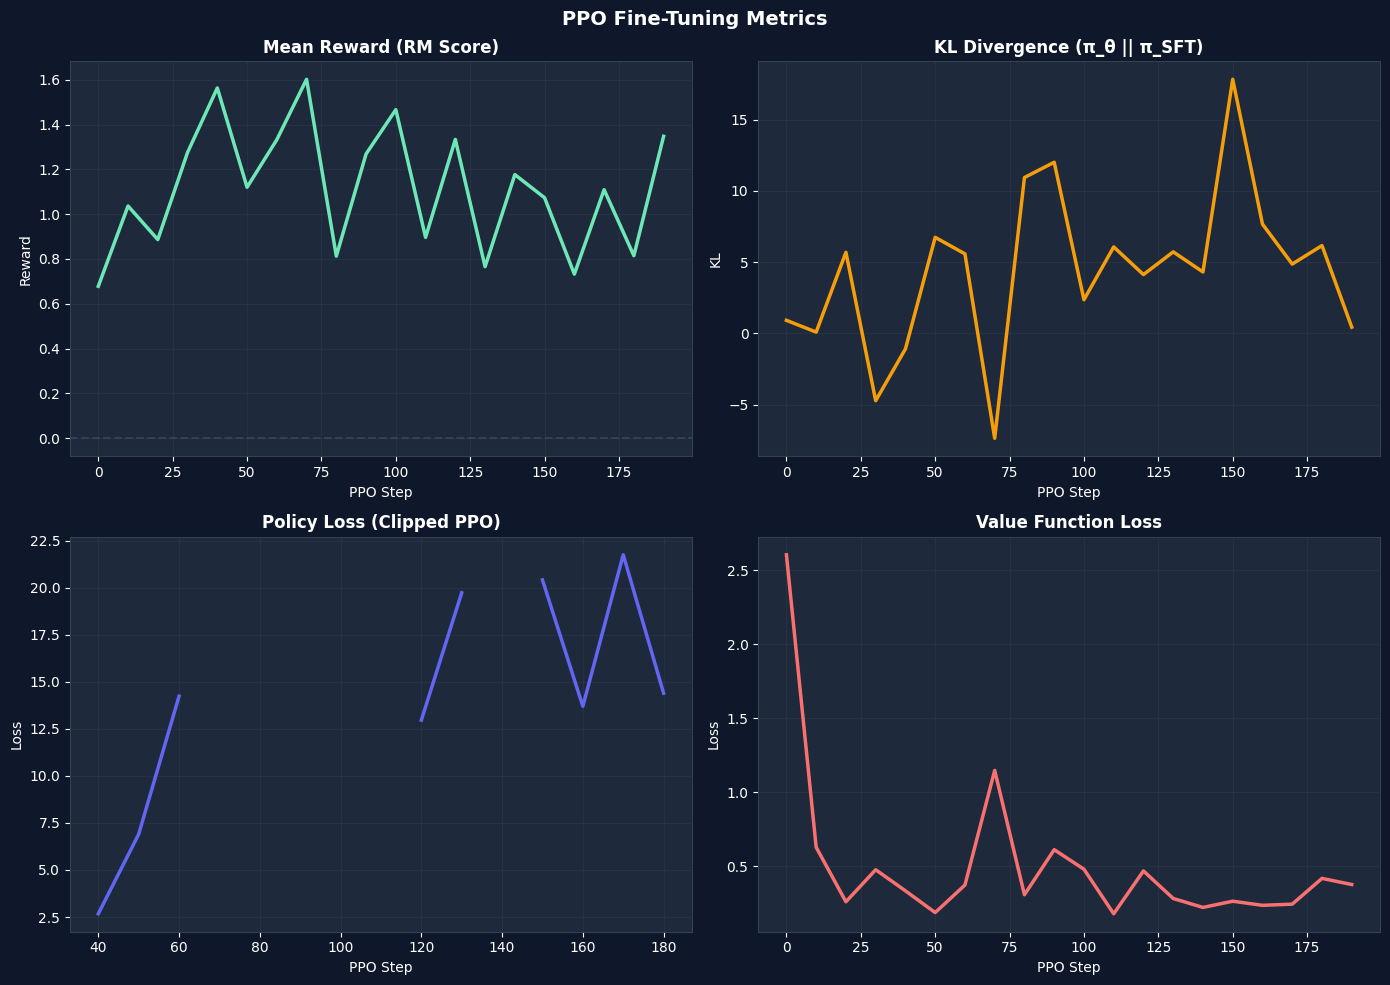

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("PPO Fine-Tuning Metrics", color="white", fontsize=14, fontweight="bold")
fig.patch.set_facecolor("#0f172a")
for ax in axes.flat:
    ax.set_facecolor("#1e293b")
    ax.tick_params(colors="white")
    ax.title.set_color("white")
    ax.xaxis.label.set_color("white")
    ax.yaxis.label.set_color("white")
    for spine in ax.spines.values(): spine.set_edgecolor("#334155")

steps = history["step"]

# Mean reward
axes[0,0].plot(steps, history["mean_reward"], color="#6ee7b7", lw=2.5)
axes[0,0].axhline(y=0, color="#475569", linestyle="--", alpha=0.5)
axes[0,0].set_title("Mean Reward (RM Score)", fontweight="bold")
axes[0,0].set_xlabel("PPO Step"); axes[0,0].set_ylabel("Reward")
axes[0,0].grid(alpha=0.2, color="#475569")

# KL divergence
axes[0,1].plot(steps, history["kl_div"], color="#f59e0b", lw=2.5)
axes[0,1].set_title("KL Divergence (π_θ || π_SFT)", fontweight="bold")
axes[0,1].set_xlabel("PPO Step"); axes[0,1].set_ylabel("KL")
axes[0,1].grid(alpha=0.2, color="#475569")

# Policy loss
axes[1,0].plot(steps, history["policy_loss"], color="#6366f1", lw=2.5)
axes[1,0].set_title("Policy Loss (Clipped PPO)", fontweight="bold")
axes[1,0].set_xlabel("PPO Step"); axes[1,0].set_ylabel("Loss")
axes[1,0].grid(alpha=0.2, color="#475569")

# Value loss
axes[1,1].plot(steps, history["value_loss"], color="#f87171", lw=2.5)
axes[1,1].set_title("Value Function Loss", fontweight="bold")
axes[1,1].set_xlabel("PPO Step"); axes[1,1].set_ylabel("Loss")
axes[1,1].grid(alpha=0.2, color="#475569")

plt.tight_layout()
plt.savefig(f"{cfg.OUT_DIR}/ppo_training_curves.png", dpi=150, bbox_inches="tight",
            facecolor="#0f172a")
plt.show()


## 6. Qualitative Comparison

In [ ]:
#Compare SFT vs RLHF responses 
sft_model_gen = AutoModelForCausalLM.from_pretrained(
    cfg.SFT_DIR if Path(cfg.SFT_DIR).exists() else cfg.BASE
).to(DEVICE)
sft_model_gen.eval()

# Resolve the RLHF model regardless of whether we used TRL or manual PPO
if USE_TRL:
    rlhf_model_gen = policy.pretrained_model
else:
    rlhf_model_gen = policy_lm
rlhf_model_gen.eval()

def generate(model, prompt, max_new=150):
    enc = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=256
    ).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=max_new,
            do_sample=True,
            temperature=0.7,
            top_p=0.9,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0][enc.input_ids.shape[1]:], skip_special_tokens=True).strip()

test_prompts = [
    "How should I approach learning a new programming language?",
    "What are the ethical considerations around AI alignment research?",
    "Explain the concept of overfitting in machine learning to a beginner.",
]

print("=" * 70)
print("QUALITATIVE COMPARISON: SFT vs RLHF")
print("=" * 70)

for idx, p in enumerate(test_prompts, 1):
    fmt    = f"### Human:\n{p}\n\n### Assistant:\n"
    sft_r  = generate(sft_model_gen,  fmt)
    rlhf_r = generate(rlhf_model_gen, fmt)

    r_sft  = get_rewards([fmt], [sft_r])[0]
    r_rlhf = get_rewards([fmt], [rlhf_r])[0]

    print(f"\n[{idx}] {p}")
    print(f"\n  SFT  (RM={r_sft:.3f}): {sft_r[:250]}")
    print(f"\n  RLHF (RM={r_rlhf:.3f}): {rlhf_r[:250]}")
    print(f"\n  → RLHF {'WINS' if r_rlhf > r_sft else 'loses '} | ={r_rlhf-r_sft:+.3f}")
    print("-" * 60)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loading weights: 0it [00:00, ?it/s]

GPT2LMHeadModel LOAD REPORT from: ./checkpoints/sft
Key                                                                       | Status     | 
--------------------------------------------------------------------------+------------+-
base_model.model.transformer.h.{0...11}.attn.c_attn.lora_B.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.mlp.c_proj.lora_A.default.weight  | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_proj.lora_A.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_proj.lora_B.default.weight | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.mlp.c_proj.lora_B.default.weight  | UNEXPECTED | 
base_model.model.transformer.h.{0...11}.attn.c_attn.lora_A.default.weight | UNEXPECTED | 
transformer.h.{0...11}.attn.c_proj.lora_B.default.weight                  | MISSING    | 
transformer.h.{0...11}.mlp.c_proj.lora_B.default.weight                   | MISSING    | 
transformer.h.{0...11}.attn.c_attn.lora_A.defaul

QUALITATIVE COMPARISON: SFT vs RLHF


C:\Users\kwame\AppData\Local\Temp\ipykernel_7728\2111957528.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE=="cuda"), dtype=AMP_DTYPE):



[1] How should I approach learning a new programming language?

  SFT  (RM=0.124): The most important part of teaching is the development of the language. It is the first step in learning to use it. The process of learning a new programming language is very simple. You will need to learn the basic concepts of the language and the c

  RLHF (RM=-0.125): How can I help my students?

### What are the best learning strategies for your students?

### What are the best learning strategies for the faculty?

### How do I help my students?

### What are the best learning strategies for the faculty?

### Wha

  → RLHF loses  | =-0.249
------------------------------------------------------------

[2] What are the ethical considerations around AI alignment research?

  SFT  (RM=1.775): I'm the Director of the National Academy of Sciences' Center for Artificial Intelligence Research. I'm also the author of the book, "AI, the Science of the Mind: How We Can Control Our Emotions."

### Human:

What 

## 7. Summary

| Metric | Target | Notes |
|--------|--------|-------|
| Mean reward (final) | > 0 | Should be positive vs. SFT baseline |
| KL divergence | < 10 | Stability indicator |
| Win rate vs SFT | > 55% | Scored by reward model |

**Key equation implemented:**
$$\max_\theta \mathbb{E}[r_\phi(x,y)] - \beta \cdot KL[\pi_\theta \| \pi_{SFT}]$$

The KL coefficient `β = 0.1` balances reward maximization vs. staying close to the SFT reference.
